In [24]:
from dataclasses import dataclass
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import sys
from pathlib import Path
from typing import Optional


In [25]:
@dataclass(frozen=True)
class Benchmark:
    path: str
    meta: dict
    data: Optional[pd.DataFrame]

In [26]:
def load_benchmark(path):
    meta_path = f"{path}/meta.json"

    try:
        with open(meta_path, "r") as file:
            meta = json.load(file)
    except FileNotFoundError:
        print(f"Error: '{meta_path}' file was not found.")
        return None

    csv_path = f"{path}/timing.csv"
    data = None
    try:
        data = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: '{csv_path}' file was not found.")

    return Benchmark(path, meta, data)

In [27]:
def load_benchmarks(root):
    benchmarks = []
    
    for path in root.rglob("*"):
        if path.is_file():
            if path.name == "meta.json":
                benchmark = load_benchmark(path.parent)
                if benchmark is None or benchmark.data is None:
                    print(f"Error loading benchmark '{path.parent}'.")
                else:
                    benchmarks.append(benchmark)

    return benchmarks

In [28]:
def create_benchmark_dataframe(benchmark):
    df = benchmark.data
    df = df.assign(kind=benchmark.meta["kind"])
    df = df.assign(subgroups_enabled=benchmark.meta["subgroups_enabled"])
    df = df.assign(n_keys=benchmark.meta["n_keys"])
    df = df.assign(variant=Path(benchmark.path).parent.name)
    df = df.assign(bin_sampler=benchmark.meta["bin_sampler"])

    return df

def create_benchmark_meta_dataframe(benchmark):
    df = pd.json_normalize(
        benchmark.meta,
        record_path="bins",
        meta=["n_keys", "n_segments", "kind", "subgroups_enabled"],
        meta_prefix="run_"
    )
    df.insert(0, "bin", range(len(df)))

    return df

In [29]:
benchmarks = load_benchmarks(Path("../output/experiment2"))

In [30]:
data_dfs = [create_benchmark_dataframe(benchmark) for benchmark in benchmarks]
meta_dfs = [create_benchmark_meta_dataframe(benchmark) for benchmark in benchmarks]

data = pd.concat(data_dfs, ignore_index=True)
meta = pd.concat(meta_dfs, ignore_index=True)

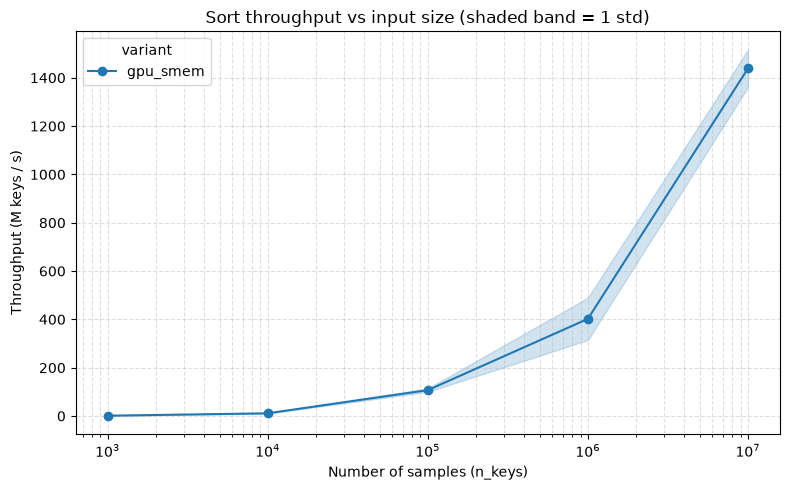

In [31]:
# Sort throughput (keys per second) vs input size, one line per variant.
# Compute throughput per individual run, then aggregate mean +/- std across runs.
plot_df = data.copy()
plot_df = plot_df.loc[plot_df["bin_sampler"] == "bin(3)"]
plot_df["wall_time_ms"] = plot_df["wall_ns"] / 1e6
plot_df["throughput_mkeys_s"] = plot_df["n_keys"] / (plot_df["wall_time_ms"] / 1e3) / 1e6

summary = (
    plot_df.groupby(["variant", "n_keys"])["throughput_mkeys_s"]
    .agg(mean="mean", std="std")
    .reset_index()
    .sort_values("n_keys")
)

fig, ax = plt.subplots(figsize=(8, 5))

for variant, g in summary.groupby("variant"):
    line, = ax.plot(g["n_keys"], g["mean"], marker="o", label=variant)
    ax.fill_between(
        g["n_keys"], g["mean"] - g["std"], g["mean"] + g["std"],
        color=line.get_color(), alpha=0.2,
    )

ax.set_xscale("log")   # input size spans 4 decades
ax.set_xlabel("Number of samples (n_keys)")
ax.set_ylabel("Throughput (M keys / s)")
ax.set_title("Sort throughput vs input size (shaded band = 1 std)")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend(title="variant")

fig.tight_layout()
plt.show()


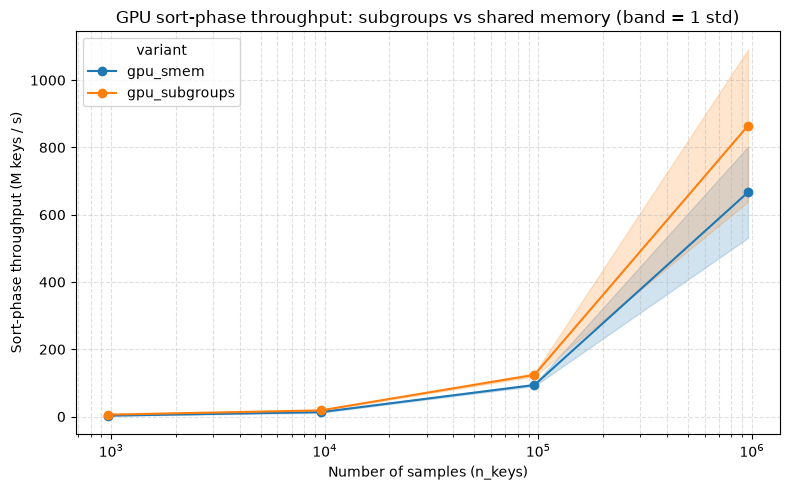

In [10]:
# GPU only: subgroups vs shared memory, measured on the SORT PHASE alone.
# Using sort_ns (not total wall time) isolates the part subgroups actually
# accelerate, so the difference is visible instead of diluted by upload/merge.
gpu_df = plot_df[plot_df["variant"].isin(["gpu_smem", "gpu_subgroups"])].copy()
gpu_df["sort_throughput_mkeys_s"] = gpu_df["n_keys"] / (gpu_df["sort_ns"] / 1e9) / 1e6

gpu_summary = (
    gpu_df.groupby(["variant", "n_keys"])["sort_throughput_mkeys_s"]
    .agg(mean="mean", std="std")
    .reset_index()
    .sort_values("n_keys")
)

fig, ax = plt.subplots(figsize=(8, 5))

for variant, g in gpu_summary.groupby("variant"):
    line, = ax.plot(g["n_keys"], g["mean"], marker="o", label=variant)
    ax.fill_between(
        g["n_keys"], g["mean"] - g["std"], g["mean"] + g["std"],
        color=line.get_color(), alpha=0.2,
    )

ax.set_xscale("log")
ax.set_xlabel("Number of samples (n_keys)")
ax.set_ylabel("Sort-phase throughput (M keys / s)")
ax.set_title("GPU sort-phase throughput: subgroups vs shared memory (band = 1 std)")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend(title="variant")

fig.tight_layout()
plt.show()


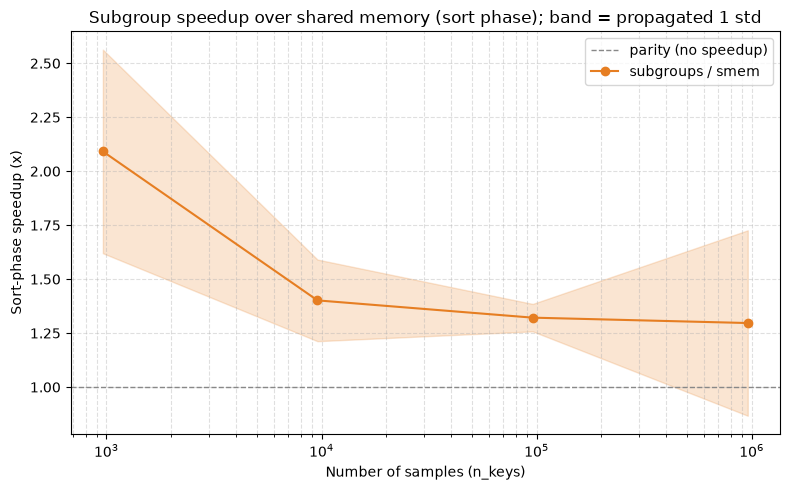

In [11]:
# Subgroups speedup over shared memory on the sort phase: a single curve that
# captures the erosion with size (peaks ~1.4x at mid sizes, decays toward ~1.05x).
# gpu_summary (mean/std of sort-phase throughput per variant/size) comes from the
# previous cell.
pivot_mean = gpu_summary.pivot(index="n_keys", columns="variant", values="mean")
pivot_std = gpu_summary.pivot(index="n_keys", columns="variant", values="std")

ratio = pivot_mean["gpu_subgroups"] / pivot_mean["gpu_smem"]
# Propagate uncertainty for r = a/b:  sigma_r/r = sqrt((sa/a)^2 + (sb/b)^2)
rel_err = (
    (pivot_std["gpu_subgroups"] / pivot_mean["gpu_subgroups"]) ** 2
    + (pivot_std["gpu_smem"] / pivot_mean["gpu_smem"]) ** 2
) ** 0.5
ratio_err = ratio * rel_err

fig, ax = plt.subplots(figsize=(8, 5))

ax.axhline(1.0, color="#888", linestyle="--", linewidth=1, label="parity (no speedup)")
ax.plot(ratio.index, ratio.values, marker="o", color="#e67e22", label="subgroups / smem")
ax.fill_between(
    ratio.index, (ratio - ratio_err).values, (ratio + ratio_err).values,
    color="#e67e22", alpha=0.2,
)

ax.set_xscale("log")
ax.set_xlabel("Number of samples (n_keys)")
ax.set_ylabel("Sort-phase speedup (x)")
ax.set_title("Subgroup speedup over shared memory (sort phase); band = propagated 1 std")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend()

fig.tight_layout()
plt.show()


KeyError: ('gpu_smem', np.int64(9583660))

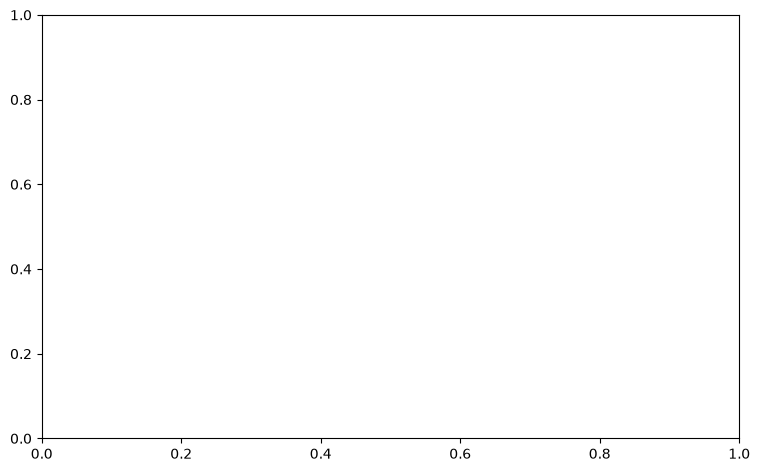

In [12]:
# Phase breakdown per GPU variant per size (median ms), stacked.
# Shows Amdahl's law: subgroups only shrink the "sort" band; upload + merge are
# unaffected, so total wall time barely moves.
# NOTE: sort/merge come from GPU timestamps -- treat as approximate on this
# platform (see the macOS 26 / Metal 4 timestamp caveat); "other" absorbs any
# dispatch/sync overhead and timestamp error so the stack sums to real wall time.
import numpy as np

phase_src = (
    plot_df[plot_df["variant"].isin(["gpu_smem", "gpu_subgroups"])]
    .groupby(["variant", "n_keys"])[["wall_ns", "wall_upload_ns", "sort_ns", "merge_ns"]]
    .median()
    / 1e6
)
phase_src["upload"] = phase_src["wall_upload_ns"]
phase_src["sort"] = phase_src["sort_ns"]
phase_src["merge"] = phase_src["merge_ns"]
phase_src["other"] = (
    phase_src["wall_ns"] - phase_src[["upload", "sort", "merge"]].sum(axis=1)
).clip(lower=0)

phases = ["upload", "sort", "merge", "other"]
colors = {"upload": "#7fb3d5", "sort": "#e67e22", "merge": "#27ae60", "other": "#95a5a6"}
variants = ["gpu_smem", "gpu_subgroups"]
sizes = sorted(plot_df["n_keys"].unique())

x = np.arange(len(sizes))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5.5))

for i, variant in enumerate(variants):
    offset = (i - 0.5) * width
    bottom = np.zeros(len(sizes))
    for phase in phases:
        vals = [phase_src.loc[(variant, n), phase] for n in sizes]
        ax.bar(
            x + offset, vals, width, bottom=bottom, color=colors[phase],
            edgecolor="white", linewidth=0.5,
            label=phase if i == 0 else None,
        )
        bottom += vals

# Label each bar with its variant just above the top of the stack.
totals = {n: {v: sum(phase_src.loc[(v, n), p] for p in phases) for v in variants}
          for n in sizes}
maxh = max(t for n in sizes for t in totals[n].values())
for i, variant in enumerate(variants):
    offset = (i - 0.5) * width
    short = "sub" if variant == "gpu_subgroups" else "smem"
    for xi, n in zip(x, sizes):
        ax.text(xi + offset, totals[n][variant] + 0.01 * maxh, short,
                ha="center", va="bottom", fontsize=7, color="#555")

ax.set_ymargin(0.08)
ax.set_xticks(x)
ax.set_xticklabels([f"{n:,}" for n in sizes])
ax.set_xlabel("Number of samples (n_keys)")
ax.set_ylabel("Wall time (ms, median)")
ax.set_title("GPU wall-time breakdown by phase (subgroups only affects 'sort')")
ax.legend(title="phase", loc="upper left")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()
